In [1]:
#import packages
import numpy as np
#import scipy.stats as scipy
#from scipy.stats import norm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


We first of all define the Euler-Scheme to generate paths of processes given by SDE's. In particular, we define a 2-dimensional Euler-Scheme. This 2-dimensionality is used in the generating process for the Heston model.

In [2]:
def euler_scheme(T, dt, R,second_true,x0,drift_x,vol1_x,W1,
                    drift_y =  lambda x,y,t: 0,vol1_y =  lambda x,y,t: 0,vol2_x = lambda x,y,t: 0,vol2_y =  lambda x,y,t: 0,y0 =  None,W2 = None):
  """
  Performs the Euler scheme for a 2D SDE.
  Args:
    T: The final time.
    dt: The time step.
    R: number of generated paths
    second_true: bool if false only one SDE
    x0: The initial value of x.
    driftx: A vector field representing the drift term in Eq.1.
    drifty: A vector field representing the drift term in Eq.2.
    vol1_x: Integrand of dW_1 in the noise term (volatility) in Eq.1.
    W1: R Brownian motion paths for first SDE
    vol2_x: Integrand of dW_1 in the noise term (volatility) in Eq.2.
    vol1_y: Integrand of dW_2 in the noise term (volatility) in Eq.1.
    vol2_y: Integrand of dW_2 in the noise term (volatility) in Eq.2.
    y0: The initial value of y.
    W2: R Brownian motion paths for second SDE
  Returns:
    A tuple containing the time points, x values, and y values.
  """
  N = int(T / dt)
  t = np.linspace(0, T, N+ 1)
  x = np.zeros((R,N+ 1))
  y = np.zeros((R,N+ 1))
  x[:,0] = x0
  if second_true:
    y[:,0] = y0
  for i in range(N):
    if second_true:
      x[:,i + 1] = np.maximum(x[:,i] + drift_x(x[:,i], y[:,i], t[i]) * dt + vol1_x(x[:,i], y[:,i], t[i]) * (W1[:,i+1]-W1[:,i]) + vol1_y(x[:,i], y[:,i], t[i]) * (W2[:,i+1]-W2[:,i]), 0)
      y[:,i + 1] = np.maximum(y[:,i] + drift_y(x[:,i], y[:,i], t[i]) * dt + vol2_x(x[:,i], y[:,i], t[i]) *  (W1[:,i+1]-W1[:,i]) + vol2_y(x[:,i], y[:,i], t[i]) * (W2[:,i+1]-W2[:,i]), 0)
    else:
      x[:,i + 1] = np.maximum(x[:,i] + drift_x(x[:,i], t[i]) * dt + vol1_x(x[:,i], t[i]) * (W1[:,i+1]-W1[:,i]),0)
  return t, x, y


In [3]:
class BSModel(object):
    def __init__(self,Npaths,T=1,dt=0.001,mu=0.2,sigma=0.2,S0=1):
        self.T = T
        self.mu = mu
        self.sigma = sigma
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.S0 = S0*np.ones((Npaths,)) #initial price
        self.BS = None
    
    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)    
        return W
    def generate(self):
        self.W = self.__generateBM()
        drift_BS = lambda x,t : self.mu*x
        volatility_BS = lambda x,t: self.sigma*x 
        _,BS,_ = euler_scheme(self.T,self.dt,self.Npaths,False,self.S0,drift_BS,volatility_BS,self.W)
        self.BS = BS
    
    def incr(self):
        if self.BS is not None:
            return np.diff(self.BS)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")
    
    def time(self):
        return np.linspace(0, self.T, self.N+ 1)
    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.BS[j, :])
            plt.title("Black-Scholes Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In [4]:
class HestonModel(object):
    def __init__(self,Npaths,T=1,dt=0.001,mu=0.2,rho=0.2, k=2, theta=0.2, xi=0.002,S0=1):
        self.T = T
        self.mu = mu
        self.rho = rho
        self.k = k
        self.theta = theta
        self.xi = xi
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.B = None #second brownian motion independent of W
        self.S0 = S0*np.ones((Npaths,)) #initial price
        self.v0 = theta*np.ones((Npaths,)) #initial variance
        self.H = None
    
    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)    
        return W
    def __corrBM(self):
        return  self.rho*self.W + np.sqrt(1-self.rho**2)*self.B
    def generate(self):
        self.W = self.__generateBM()
        self.B = self.__generateBM()
        drift_H_x = lambda x,y,t: self.mu*x
        volH_1_x = lambda x,y,t: np.sqrt(y)*x
        drift_H_y = lambda x,y,t: self.k*(self.theta-y)
        volH_2_y = lambda x,y,t: self.xi*np.sqrt(y)
        _, H, volatility_H = euler_scheme(self.T,self.dt,self.Npaths,True,x0 = self.S0,drift_x = drift_H_x,
                                    vol1_x = volH_1_x,W1 = self.W,
                                    drift_y = drift_H_y,vol2_y = volH_2_y,y0 = self.v0, W2 = self.__corrBM())
        self.volatility_H = volatility_H
        self.H = H
    
    def incr(self):
        if self.H is not None:
            return np.diff(self.H)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")
    
    def time(self):
        return np.linspace(0, self.T, self.N+ 1)
    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.H[j, :])
            plt.title("Heston Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In [5]:
class CEVModel(object):
    def __init__(self,Npaths,T = 1,dt = 0.001,mu=0.2,sigma=0.2,gamma=0.4,S0=1):
        self.T = T
        self.mu = mu
        self.sigma = sigma
        self.gamma = gamma
        self.N = int(T/dt)
        self.dt = dt
        self.Npaths = Npaths
        self.W = None #Paths of BM with discretization int(T/dt) and Npaths different paths
        self.S0 = S0*np.ones((Npaths,)) #initial price
        self.CEV = None

    def __generateBM(self):
        dW =  np.sqrt(self.dt)*np.random.randn(self.N*self.Npaths).reshape((self.Npaths,self.N))
        W = np.concatenate((np.zeros((self.Npaths,1)),np.cumsum(dW,axis = 1)),axis =1)    
        return W
    def generate(self):
        self.W = self.__generateBM()
        drift_CEV_x = lambda x,t: self.mu*x
        volCEV_1_x = lambda x,t: self.sigma*x**self.gamma
        _,CEV,_ = euler_scheme(self.T,self.dt,self.Npaths,False,self.S0,drift_CEV_x,volCEV_1_x,self.W)
        self.CEV = CEV
    
    def incr(self):
        if self.CEV is not None:
            self.incr = np.diff(self.CEV)
        else:
            raise ValueError("The paths have not been generated yet. Please run the 'generate' method first.")
    
    def time(self):
        return np.linspace(0, self.T, self.N+ 1)
    
    def plot(self):
        for j in range(self.Npaths):
            plt.plot(self.time(), self.CEV[j, :])
            plt.title("CEV Model Trajectories")
            plt.xlabel("Time")
            plt.ylabel("Price")
            plt.show()

In [6]:
eta = 0.7

def utility(x):
    return (x**(1-eta))/(1-eta)

In [7]:
class TradingStrategyModel(nn.Module):
    def __init__(self, num_layers=3, n=32, N=None, r=None, T=None, sigma=None):
        super(TradingStrategyModel, self).__init__()
        
        self.m = 1 #dimension of the price
        self.num_layers = num_layers
        self.n = n # nodes in the first but last layers
        self.N = N
        self.r = r
        self.T = T
        self.sigma = sigma
        
        self.networks = nn.ModuleList() # Create for each time step of the discretization starting at t=1,...,N
        for j in range(N):
            layers = []
            for i in range(num_layers):
                if i < num_layers-1: #add activation until last layer
                    if i == 0:
                        layers.append(nn.Linear(self.m, n))   # First layer takes input of size 1 (wealth)
                    else:
                        layers.append(nn.Linear(n, n))
                    layers.append(nn.Tanh())
                else:
                    # Output layer with linear activation
                    layers.append(nn.Linear(n, self.m)) #Output Layer 
            
            # Create a sequential network for this time step
            network = nn.Sequential(*layers)
            
            # # Initialize weights and biases with N(0, 0.5) #TODO: check
            # for layer in network:
            #     if isinstance(layer, nn.Linear):
            #         nn.init.normal_(layer.weight, mean=0, std=0.5)
            #         nn.init.normal_(layer.bias, mean=0, std=0.5)
            
            self.networks.append(network)
    
    def forward(self, price, tradeeval, wealth,incr_list):
        strategies_eval = []
        
        for j in range(self.N):
            # Apply the j-th strategy network to get alpha
            strategy = self.networks[j](wealth)
            strategy_eval = self.networks[j](tradeeval)
            strategies_eval.append(strategy_eval)
            
            # Get price increment for this step
            incr = incr_list[j]
            
            # Update price
            log_price = torch.log(price)
            log_price = log_price + incr
            price = torch.exp(log_price)
            
            # Update wealth using the strategy
            log_wealth = torch.log(wealth)
            log_wealth = log_wealth + self.r * self.T / self.N
            
            # Apply trading strategy effects
            helper1 = strategy * incr
            log_wealth = log_wealth + helper1
            
            helper2 = strategy * strategy
            helper3 = helper2 * (self.sigma**2 / 2) * (self.T / self.N)
            log_wealth = log_wealth - helper3
            
            helper4 = strategy * self.r * self.T / self.N
            log_wealth = log_wealth - helper4
            
            # Get new wealth
            wealth = torch.exp(log_wealth)
        
        # Add random endowment term
        random_endowment = -0.0 * (torch.abs(price - 1.0) + price - 1.0)
        final_output = wealth + random_endowment
        
        # Concatenate outputs
        outputs = [final_output] + strategies_eval
        return torch.cat(outputs, dim=1)

In [ ]:
class TradingModelTrainer:
    def __init__(self, model,price_model_str, lr=0.001, utility_function="log"):
        self.model = model
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.utility_function = utility_function
        self.price_model_str = price_model_str #either 'BS', 'H' or 'CEV'
    def utility(self, wealth):
        if self.utility_function == "log":
            return torch.log(wealth)
        elif self.utility_function == "power":
            gamma = 0.5  # risk aversion parameter
            return (wealth ** (1 - gamma)) / (1 - gamma)
        else:
            raise ValueError(f"Unknown utility function: {self.utility_function}")
    
    def loss_function(self, terminal_wealth):
        utility_vals = self.utility(terminal_wealth)
        return -torch.mean(utility_vals)  # Negative because we want to maximize utility
    
    def generate_training_data(self, batch_size, num_batches):
        #First we need to create price_model
        if self.price_model_str == 'BS':
            price_model = BSModel(batch_size)
            price_model.generate()
        elif self.price_model_str == 'H':
            price_model = HestonModel(batch_size)
            price_model.generate()
        elif self.price_model_str == 'CEV':
            price_model = CEVModel(batch_size)
            price_model.generate()
        else:
            ValueError(f"Unknown price model: {price_model}")


        all_data = []
        
        for _ in range(num_batches):
            # Initial conditions
            price = torch.ones(batch_size, self.model.m)
            tradeeval = torch.zeros(batch_size, self.model.m)
            wealth = torch.ones(batch_size, 1)
            
            incr_list = torch.tensor(price_model.incr())
            batch_data = (price, tradeeval, wealth) + tuple(incr_list)
            all_data.append(batch_data)
        return all_data
    
    def train(self, num_epochs=100, batch_size=128,num_batches = 50, verbose=True):
        losses = []
        for epoch in range(num_epochs):
            epoch_loss = 0
            
            # Generate new training data for this epoch
            training_data = self.generate_training_data(batch_size,num_batches)
            
            for batch_idx, batch in enumerate(training_data):
                self.optimizer.zero_grad()
                
                # Forward pass
                outputs = self.model(batch[0],batch[1],batch[2],batch[3])
                
                # Extract terminal wealth (first element of the output)
                terminal_wealth = outputs[:, 0].view(-1, 1)
                
                # Calculate loss
                loss = self.loss_function(terminal_wealth)
                
                # Backward pass and optimization
                loss.backward()
                self.optimizer.step()
                
                epoch_loss += loss.item()
                
                if verbose and batch_idx % 10 == 0:
                    print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{num_batches}, '
                          f'Loss: {loss.item():.6f}, Mean Terminal Wealth: {terminal_wealth.mean().item():.4f}')
            
            avg_epoch_loss = epoch_loss / num_batches
            losses.append(avg_epoch_loss)
            
            if verbose:
                print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_epoch_loss:.6f}')
        
        return losses
    
    def evaluate_model(self, num_simulations=1000):
        """
        Evaluate the trained model using Monte Carlo simulations
        
        Args:
            num_simulations: Number of price paths to simulate
        
        Returns:
            Mean terminal wealth, mean utility, and terminal wealth distribution
        """
        self.model.eval()  # Set model to evaluation mode
        
        with torch.no_grad():
            # Generate evaluation data
            eval_data = self.generate_training_data(num_simulations, 1)[0]
            
            # Forward pass
            outputs = self.model(eval_data[0],eval_data[1],eval_data[2],eval_data[3])
            
            # Extract terminal wealth
            terminal_wealth = outputs[:, 0].view(-1, 1)
            
            # Calculate utility
            utility_vals = self.utility(terminal_wealth)
            
            # Return statistics
            mean_wealth = terminal_wealth.mean().item()
            mean_utility = utility_vals.mean().item()
            wealth_distribution = terminal_wealth.numpy().flatten()
            
            return mean_wealth, mean_utility, wealth_distribution

    def plot_training_results(self, losses, wealth_distribution=None):
        plt.figure(figsize=(12, 5))
        
        # Plot loss history
        plt.subplot(1, 2, 1)
        plt.plot(losses)
        plt.title('Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Neg. Expected Utility')
        
        # Plot wealth distribution if provided
        if wealth_distribution is not None:
            plt.subplot(1, 2, 2)
            plt.hist(wealth_distribution, bins=30, alpha=0.7)
            plt.title('Terminal Wealth Distribution')
            plt.xlabel('Terminal Wealth')
            plt.ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()

Epoch 1/50, Batch 1/1, Loss: -0.008608, Mean Terminal Wealth: 1.0086
Epoch 1/50, Average Loss: -0.008608
Epoch 2/50, Batch 1/1, Loss: -0.043634, Mean Terminal Wealth: 1.0446
Epoch 2/50, Average Loss: -0.043634
Epoch 3/50, Batch 1/1, Loss: 0.039239, Mean Terminal Wealth: 0.9615
Epoch 3/50, Average Loss: 0.039239
Epoch 4/50, Batch 1/1, Loss: -0.070184, Mean Terminal Wealth: 1.0727
Epoch 4/50, Average Loss: -0.070184
Epoch 5/50, Batch 1/1, Loss: -0.008515, Mean Terminal Wealth: 1.0086
Epoch 5/50, Average Loss: -0.008515
Epoch 6/50, Batch 1/1, Loss: 0.059157, Mean Terminal Wealth: 0.9426
Epoch 6/50, Average Loss: 0.059157
Epoch 7/50, Batch 1/1, Loss: -0.082384, Mean Terminal Wealth: 1.0859
Epoch 7/50, Average Loss: -0.082384
Epoch 8/50, Batch 1/1, Loss: -0.092460, Mean Terminal Wealth: 1.0969
Epoch 8/50, Average Loss: -0.092460
Epoch 9/50, Batch 1/1, Loss: -0.048082, Mean Terminal Wealth: 1.0493
Epoch 9/50, Average Loss: -0.048082
Epoch 10/50, Batch 1/1, Loss: -0.085977, Mean Terminal Weal

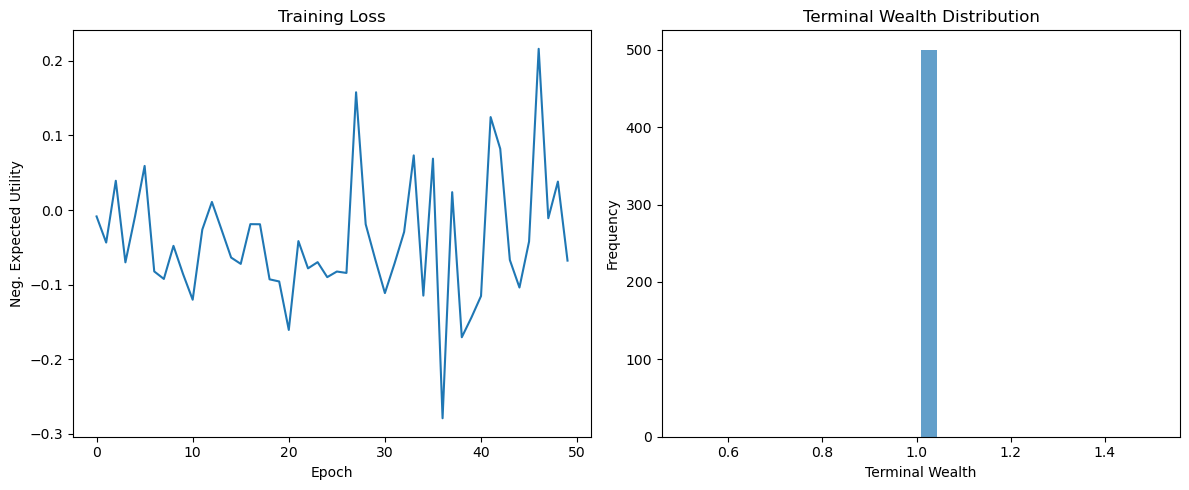

In [ ]:
def train_trading_model(num_layers = 3, n=32, N=10000, r=0.05, T=1.0, sigma=0.2):
    model = TradingStrategyModel(num_layers=num_layers, n=n, N=N, r=r, T=T, sigma=sigma)
    
    trainer = TradingModelTrainer(model,'BS', lr=0.001, utility_function="log")
    
    losses = trainer.train(num_epochs=50, batch_size=100, num_batches=1)
    
    mean_wealth, mean_utility, wealth_distribution = trainer.evaluate_model(num_simulations=500)
    
    print(f"Mean Terminal Wealth: {mean_wealth:.4f}")
    print(f"Mean Utility: {mean_utility:.4f}")
    
    trainer.plot_training_results(losses, wealth_distribution)
    
    return model, trainer